In [1]:
%pip install pandas numpy matplotlib pyfixest

  Using cached scipy-1.15.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached scipy-1.15.3-cp313-cp313-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.3 MB)
  Attempting uninstall: scipy
    Found existing installation: scipy 1.17.1
    Uninstalling scipy-1.17.1:
      Successfully uninstalled scipy-1.17.1
Note: you may need to restart the kernel to use updated packages.


# Imports

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import pyfixest as pf


import os

folder_path = "../output/simulations_revision_regression"

# Tests


FileNotFoundError: [Errno 2] No such file or directory: '../output/simulations_revision_regression/V_0.00.npy'

In [ ]:
policy = np.load(os.path.join(folder_path,f"I_policy_s{test}1.npy"))
D_grid = np.load(os.path.join(folder_path,f"grid_D.npy"))


array([5.39812978, 5.43145542, 5.46478107, 5.49810671, 5.53143236,
       5.564758  , 5.59808365, 5.6314093 , 5.66473494, 5.69806059,
       5.73138623, 5.76471188, 5.79803753, 5.83136317, 5.86468882,
       5.89801446, 5.93134011, 5.96466575, 5.9979914 , 6.03131705,
       6.06464269, 6.09796834, 6.13129398, 6.16461963, 6.19794528,
       6.23127092, 6.26459657, 6.29792221, 6.33124786, 6.3645735 ,
       6.39789915, 6.4312248 , 6.46455044, 6.49787609, 6.53120173,
       6.56452738, 6.59785303, 6.63117867, 6.66450432, 6.69782996,
       6.73115561, 6.76448125, 6.7978069 , 6.83113255, 6.86445819,
       6.89778384, 6.93110948, 6.96443513, 6.99776078, 7.03108642])

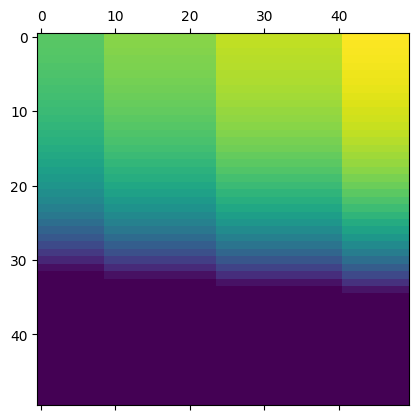

In [144]:
plt.matshow(policy[:,:,0])

In [125]:

panel_1 = pd.read_csv(os.path.join(folder_path,f"panel_data_s{test}1.csv"))
panel_1

,firm_id,year,K,D,D_half,sigma,sigma_half,log_D,log_D_half,log_sigma,log_sigma_half,I,Delta_I,I_total,I_rate,profit,E_last_semester,E_beginning,E_half
0,1,1,0.005366,353.252353,366.731325,0.099625,0.099477,5.867183,5.904629,-2.306345,-2.307829,0.021436,0.0,0.021436,3.994965,0.283645,NaN,0.021436,0.021436
1,1,2,0.002197,332.606567,383.221969,0.099335,0.099379,5.806960,5.948614,-2.309256,-2.308813,0.021753,0.0,0.021753,9.900015,0.258223,0.021983,0.021753,0.021753
2,1,3,0.002197,401.216754,381.581959,0.099465,0.099513,5.994502,5.944326,-2.307950,-2.307465,0.021753,0.0,0.021753,9.900000,0.279944,0.021983,0.021753,0.021753
3,1,4,0.002197,462.624117,502.605565,0.099369,0.099258,6.136915,6.219806,-2.308918,-2.310029,0.021753,0.0,0.021753,9.900000,0.338076,0.021983,0.021753,0.021753
4,1,5,0.002197,486.395531,487.918551,0.099407,0.099282,6.187022,6.190148,-2.308529,-2.309795,0.021753,0.0,0.021753,9.900000,0.340967,0.067420,0.021753,0.021753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,1000,996,0.002197,237.375763,217.602156,0.100752,0.100641,5.469644,5.382668,-2.295091,-2.296192,0.021753,0.0,0.021753,9.900000,0.171688,0.021983,0.021753,0.021753
999996,1000,997,0.002197,203.305798,201.799625,0.100698,0.100763,5.314711,5.307275,-2.295627,-2.294986,0.021753,0.0,0.021753,9.900000,0.154651,0.021983,0.021753,0.021753
999997,1000,998,0.002197,182.981138,190.397619,0.100645,0.100519,5.209383,5.249115,-2.296155,-2.297409,0.021753,0.0,0.021753,9.900000,0.143693,0.021983,0.021753,0.021753
999998,1000,999,0.002197,195.671252,170.095324,0.100615,0.100483,5.276436,5.136359,-2.296452,-2.297767,0.021753,0.0,0.021753,9.900000,0.141023,0.021983,0.021753,0.021753


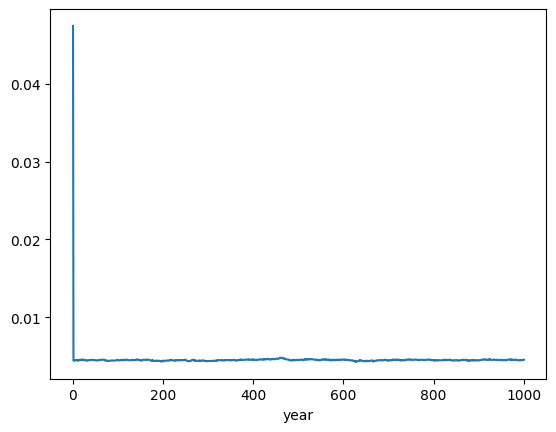

In [126]:

test = 1 
panel_1 = pd.read_csv(os.path.join(folder_path,f"panel_data_s{test}1.csv"))
panel_1.groupby(['year']).K.mean().plot()
panel_1 = panel_1.groupby(['firm_id']).tail(700)
panel_1['q'] = pd.qcut(panel_1.D,q = 10,    labels=np.arange(1,11))
panel_1 = panel_1.query('firm_id == 1')
panel_1['D_lag1'] = panel_1.groupby('firm_id')['profit'].shift(1)

panel_1['autocorr_1'] = panel_1.groupby('firm_id')['profit'].transform(
    lambda x: x.autocorr(lag=1)
)

<Axes: xlabel='year'>

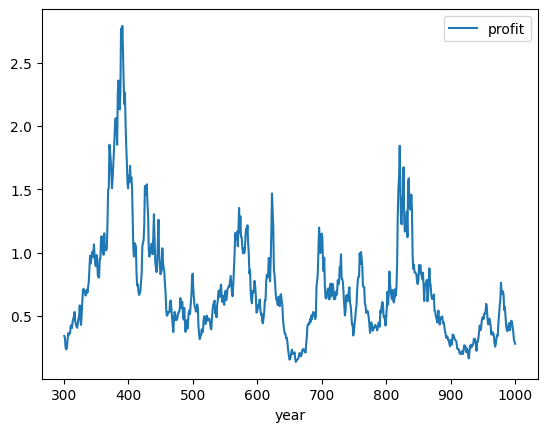

In [115]:
panel_1.plot(x = "year",y = 'profit')

<Axes: xlabel='year'>

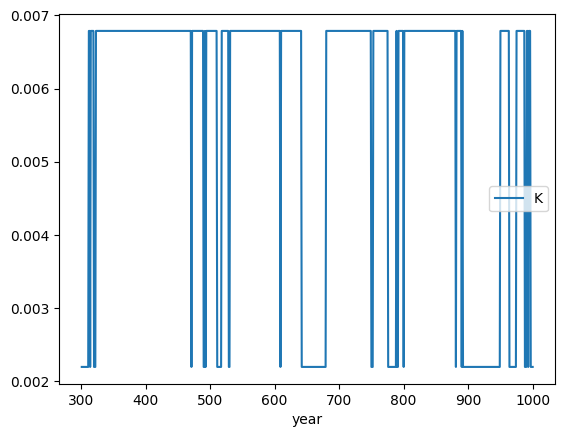

In [130]:
panel_1.query('firm_id == 1').plot(x = "year",y = 'K')

In [56]:
panel_1.query('firm_id == 1').head(50)

,firm_id,year,K,D,D_half,sigma,sigma_half,log_D,log_D_half,log_sigma,log_sigma_half,I,Delta_I,I_total,I_rate,profit,E_last_semester,E_beginning,E_half
300,1,301,1.801827,479.256305,413.334165,0.102551,0.093792,6.172236,6.024256,-2.277399,-2.366677,0.189929,0.0,0.189929,0.105409,0.612475,0.189929,0.189929,0.189929
301,1,302,1.801827,513.539680,420.683309,0.091228,0.117113,6.241327,6.041880,-2.394388,-2.144616,0.189929,0.0,0.189929,0.105409,0.638026,0.189929,0.189929,0.189929
302,1,303,1.801827,380.139843,403.706233,0.115482,0.104338,5.940539,6.000687,-2.158642,-2.260123,0.189929,0.0,0.189929,0.105409,0.544937,0.189929,0.189929,0.189929
303,1,304,1.801827,462.825553,410.026966,0.098588,0.093141,6.137350,6.016223,-2.316805,-2.373637,0.189929,0.0,0.189929,0.105409,0.600308,0.189929,0.189929,0.189929
304,1,305,1.801827,472.568972,542.165265,0.091839,0.083495,6.158184,6.295571,-2.387720,-2.482972,0.189929,0.0,0.189929,0.105409,0.687517,0.189929,0.189929,0.189929
305,1,306,1.801827,547.098658,626.660535,0.090717,0.094720,6.304629,6.440405,-2.400014,-2.356832,0.189929,0.0,0.189929,0.105409,0.783874,0.189929,0.189929,0.189929
306,1,307,1.801827,601.603636,585.426779,0.098327,0.086687,6.399599,6.372341,-2.319460,-2.445456,0.189929,0.0,0.189929,0.105409,0.792010,0.189929,0.189929,0.189929
307,1,308,1.801827,522.584053,469.977619,0.091880,0.090430,6.258786,6.152685,-2.387268,-2.403174,0.189929,0.0,0.189929,0.105409,0.674025,0.189929,0.189929,0.189929
308,1,309,1.801827,498.376591,532.321508,0.086234,0.091327,6.211356,6.277248,-2.450689,-2.393308,0.189929,0.0,0.189929,0.105409,0.697366,0.189929,0.189929,0.189929
309,1,310,1.801827,482.992477,550.921074,0.111832,0.102472,6.180001,6.311592,-2.190755,-2.278167,0.189929,0.0,0.189929,0.105409,0.699225,0.189929,0.189929,0.189929


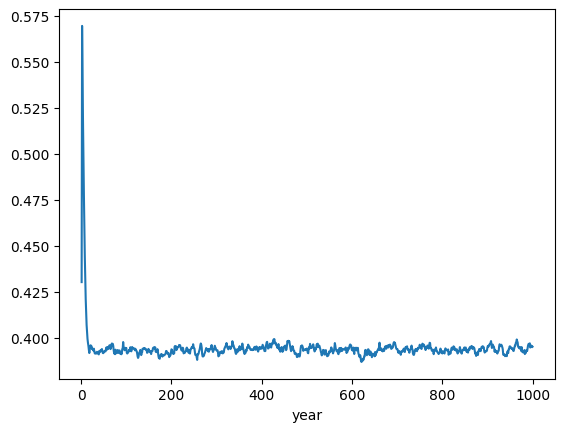

In [150]:
test = 1 
panel_1 = pd.read_csv(os.path.join(folder_path,f"panel_data_s{test}1.csv"))
panel_1.groupby(['year']).K.mean().plot()
panel_1 = panel_1.groupby(['firm_id']).tail(700)

In [200]:
panel_1['Rev_0'] = np.log(panel_1['E_beginning'])-np.log(panel_1['E_last_semester'])
panel_1['Rev_1'] = np.log(panel_1['E_half'])-np.log(panel_1['E_beginning'])


mu_D = np.log(500)
rho_D = 0.5

panel_1['m_t'] = mu_D*(1-rho_D) + rho_D*panel_1.log_D
panel_1['Var_D_pred'] = (np.exp(panel_1.sigma**2)-1)*np.exp(2*mu_D+panel_1.sigma**2)/10000
panel_1['D_pred'] = np.exp(panel_1.m_t + 1/2*panel_1.sigma**2)
panel_1['Var_D_pred_1'] = panel_1.groupby(['firm_id']).Var_D_pred.transform("shift")

pf.feols("Rev_0 ~ Var_D_pred + D_pred + K | firm_id ",panel_1).summary()

/opt/python/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/python/lib/python3.13/site-packages/pyfixest/estimation/model_matrix_fixest_.py:159: UserWarning: 82919 rows with infinite values detected. These rows are dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: Rev_0, Fixed effects: firm_id
Inference:  iid
Observations:  617081

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |    2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|--------:|--------:|
| Var_D_pred    |     -0.134 |        0.014 |    -9.328 |      0.000 |  -0.162 |  -0.106 |
| D_pred        |      0.014 |        0.000 |   543.109 |      0.000 |   0.013 |   0.014 |
| K             |    -10.196 |        0.023 |  -437.893 |      0.000 | -10.242 | -10.151 |
---
RMSE: 0.602 R2: 0.326 R2 Within: 0.325 


300       2540.807061
301       2213.472383
302       3014.421469
303       2351.603833
304       2263.557474
             ...     
999995    2063.235858
999996    2818.121833
999997    2065.008736
999998    3035.085703
999999    2079.608838
Name: Var_D_pred, Length: 700000, dtype: float64

In [158]:
sigma2 = np.exp(2 * panel_1['log_sigma'])

panel_1['var_D'] = np.exp(2 * panel_1['log_D'] + sigma2) * (np.exp(sigma2) - 1)